## HW 6 Pt 2
Author: Minji Kang <br>
Date: 3/29/2025 <br>
Description: EDA with sub-goal- Explore if any college programs consistently grow players with above-average or below-average advanced NBA metrics (Duke, Kentucky, Chapel Hill, etc.). <br>

Used this article to help with mapping: https://medium.com/@alex_44314/use-python-geopandas-to-make-a-us-map-with-alaska-and-hawaii-39a9f5c222c6

In [166]:
# importing pandas for dataframes
import pandas as pd
# importing geopandas for mapping
import geopandas
import geopy
from geopy.geocoders import Nominatim
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Read in the merged dataset
mergedDF = pd.read_csv("https://raw.githubusercontent.com/hpatel-27/DataScience_CourseProject/refs/heads/main/datasets/merged_playerStats.csv", index_col=0)

# Read in players dataset
players = pd.read_csv("https://raw.githubusercontent.com/hpatel-27/DataScience_CourseProject/refs/heads/main/datasets/Players.csv", index_col=0)


In [167]:
mergedDF.columns

Index(['height', 'weight', 'college', 'Year', 'Pos', 'Age', 'G', 'MP', 'PER',
       'TS%', 'USG%', 'WS', 'BPM', 'VORP', 'FG%', '3P%', '2P%', 'eFG%', 'FT%',
       'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PTS'],
      dtype='object')

In [168]:
players.columns

Index(['Player', 'height', 'weight', 'collage', 'born', 'birth_city',
       'birth_state'],
      dtype='object')

In [169]:
# getting birth location from original players dataset since it was dropped for merged dataset
locationDF = players[['birth_city', 'birth_state']]
# setting index as player name
locationDF.index = players['Player']
# adding advanced metrics and college name
locationDF = locationDF.join(mergedDF[['college', 'BPM', 'VORP', 'WS']])
locationDF

,birth_city,birth_state,college,BPM,VORP,WS
Player,,,,,,
Curly Armstrong,NaN,NaN,Indiana University,NaN,NaN,2.408911
Cliff Barker,Yorktown,Indiana,University of Kentucky,NaN,NaN,0.677852
Leo Barnhorst,NaN,NaN,University of Notre Dame,NaN,NaN,NaN
Ed Bartels,NaN,NaN,North Carolina State University,NaN,NaN,-0.538298
Ralph Beard,Hardinsburg,Kentucky,University of Kentucky,NaN,NaN,5.690476
...,...,...,...,...,...,...
Troy Williams,Columbia,South Carolina,South Carolina State University,-2.76,-0.09,0.180000
Kyle Wiltjer,Portland,Oregon,Gonzaga University,-4.00,0.00,0.000000
Stephen Zimmerman,Hendersonville,Tennessee,"University of Nevada, Las Vegas",-7.30,-0.10,0.000000


In [170]:
# dropping row if birth location is not available
birthDF = locationDF.dropna(subset=['birth_state'])
birthDF.reset_index(inplace=True)
birthDF

,Player,birth_city,birth_state,college,BPM,VORP,WS
0,Cliff Barker,Yorktown,Indiana,University of Kentucky,NaN,NaN,0.677852
1,Ralph Beard,Hardinsburg,Kentucky,University of Kentucky,NaN,NaN,5.690476
2,Charlie Black,Arco,Idaho,University of Kansas,NaN,NaN,1.877622
3,Nelson Bobb,Philadelphia,Pennsylvania,Temple University,NaN,NaN,1.521145
4,Jake Bornheimer,New Brunswick,New Jersey,Muhlenberg College,NaN,NaN,0.800000
...,...,...,...,...,...,...,...
3434,Troy Williams,Columbia,South Carolina,South Carolina State University,-2.76,-0.09,0.180000
3435,Kyle Wiltjer,Portland,Oregon,Gonzaga University,-4.00,0.00,0.000000
3436,Stephen Zimmerman,Hendersonville,Tennessee,"University of Nevada, Las Vegas",-7.30,-0.10,0.000000
3437,Paul Zipser,Heidelberg,Germany,NaN,-3.70,-0.40,0.500000


In [171]:
# dropping row if college is not available
collegeDF = locationDF.dropna(subset=['college'])
collegeDF.reset_index(inplace=True)
collegeDF

,Player,birth_city,birth_state,college,BPM,VORP,WS
0,Curly Armstrong,NaN,NaN,Indiana University,NaN,NaN,2.408911
1,Cliff Barker,Yorktown,Indiana,University of Kentucky,NaN,NaN,0.677852
2,Leo Barnhorst,NaN,NaN,University of Notre Dame,NaN,NaN,NaN
3,Ed Bartels,NaN,NaN,North Carolina State University,NaN,NaN,-0.538298
4,Ralph Beard,Hardinsburg,Kentucky,University of Kentucky,NaN,NaN,5.690476
...,...,...,...,...,...,...,...
3568,Okaro White,Clearwater,Florida,Florida State University,-2.10,0.00,0.600000
3569,Isaiah Whitehead,Brooklyn,New York,Seton Hall University,-4.90,-1.20,-0.800000
3570,Troy Williams,Columbia,South Carolina,South Carolina State University,-2.76,-0.09,0.180000
3571,Kyle Wiltjer,Portland,Oregon,Gonzaga University,-4.00,0.00,0.000000


In [172]:
# connecting to github to get folder with US Census map data
check = !git status
if 'main' not in check[0]:
  !git clone https://github.com/hpatel-27/DataScience_CourseProject.git
if 'mkang8' not in check[0]:
  !git checkout mkang8
  %cd DataScience_CourseProject/
else:
  print('Already connected to GitHub')

fatal: destination path 'DataScience_CourseProject' already exists and is not an empty directory.
Already connected to GitHub


In [173]:
!ls

cb_2018_us_state_500k	   datasets	 meeting_minutes     project.ipynb  stats_explained.txt
DataScience_CourseProject  dictionaries  mkang8EDAhw6.ipynb  README.md


In [174]:
# reading folder into geopandas
gdf = geopandas.read_file("cb_2018_us_state_500k")
gdf

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ..."
1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ..."
2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6..."
3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ..."
4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,..."
5,22,01629543,0400000US22,22,LA,Louisiana,00,111897594374,23753621895,"MULTIPOLYGON (((-88.8677 29.86155, -88.86566 2..."
6,26,01779789,0400000US26,26,MI,Michigan,00,146600952990,103885855702,"MULTIPOLYGON (((-83.19159 42.03537, -83.18993 ..."
7,25,00606926,0400000US25,25,MA,Massachusetts,00,20205125364,7129925486,"MULTIPOLYGON (((-70.23405 41.28565, -70.22361 ..."
8,16,01779783,0400000US16,16,ID,Idaho,00,214049787659,2391722557,"POLYGON ((-117.24267 44.39655, -117.23484 44.3..."
9,12,00294478,0400000US12,12,FL,Florida,00,138949136250,31361101223,"MULTIPOLYGON (((-80.17628 25.52505, -80.17395 ..."


In [175]:
# filter if state is Hawaii or Alaska
print('Hawaii: ' + str(birthDF[birthDF['birth_state'] == 'Hawaii'].shape[0]))
print('Alaska: ' + str(birthDF[birthDF['birth_state'] == 'Alaska'].shape[0]))

Hawaii: 2
Alaska: 1


In [176]:
# omitting territories, Hawaii, and Alaska for easier graphing
gdfMain = gdf[gdf['NAME'] != 'Hawaii']
gdfMain = gdfMain[gdfMain['NAME'] != 'Alaska']
gdfMain = gdfMain[gdfMain['NAME'] != 'Commonwealth of the Northern Mariana Islands']
gdfMain = gdfMain[gdfMain['NAME'] != 'Guam']
gdfMain = gdfMain[gdfMain['NAME'] != 'United States Virgin Islands']
gdfMain = gdfMain[gdfMain['NAME'] != 'American Samoa']
gdfMain = gdfMain[gdfMain['NAME'] != 'Puerto Rico']

In [177]:
# grouping by birth state
countByBirth = birthDF[['Player', 'birth_state']].groupby('birth_state').count().sort_values(by='Player', ascending=False)
countByBirth.rename(columns={'Player': 'count'}, inplace=True)
countByBirth['avgBPM'] = birthDF[['BPM', 'birth_state']].groupby('birth_state').mean()
countByBirth['avgVORP'] = birthDF[['VORP', 'birth_state']].groupby('birth_state').mean()
countByBirth['avgWS'] = birthDF[['WS', 'birth_state']].groupby('birth_state').mean()
countByBirth

,count,avgBPM,avgVORP,avgWS
birth_state,,,,
California,344,-3.218891,0.324080,1.833804
New York,290,-3.616189,0.307460,1.895069
Illinois,209,-3.485964,0.340218,1.846287
Pennsylvania,163,-3.520430,0.261479,1.896942
Ohio,137,-4.011986,0.309761,2.184057
...,...,...,...,...
South Africa,1,0.923747,2.007888,8.034347
United Republic of Tanzania,1,-2.596907,0.103780,1.093814
Tunisia,1,0.485981,0.436449,2.459813


In [178]:
# grouping by colleges
countByCollege = collegeDF[['Player', 'college']].groupby('college').count().sort_values(by='Player', ascending=False)
countByCollege.rename(columns={'Player': 'count'}, inplace=True)
countByCollege['avgBPM'] = collegeDF[['BPM', 'college']].groupby('college').mean()
countByCollege['avgVORP'] = collegeDF[['VORP', 'college']].groupby('college').mean()
countByCollege['avgWS'] = collegeDF[['WS', 'college']].groupby('college').mean()
countByCollege

,count,avgBPM,avgVORP,avgWS
college,,,,
University of Kentucky,89,-2.117872,0.471478,2.338307
"University of California, Los Angeles",86,-2.461690,0.504430,2.397671
University of North Carolina,67,-2.914886,0.550868,2.391155
University of Kansas,59,-4.116373,0.152078,1.731890
Duke University,56,-2.493560,0.399600,2.197326
...,...,...,...,...
Belmont Abbey College,1,NaN,NaN,0.100000
Beloit College,1,NaN,NaN,-0.057353
Belmont University,1,-2.749558,-0.078761,1.076106


In [197]:
# creating geo dataframe for birth states
gdfBirth = gdfMain.join(countByBirth, on='NAME')

In [198]:
# creating colors for heatmap
norm = mcolors.Normalize(gdfBirth['count'].min(), gdfBirth['count'].max())
mapper = plt.cm.ScalarMappable(norm=norm, cmap=plt.cm.YlOrBr)
gdfBirth['color'] = gdfBirth['count'].apply(lambda x: mcolors.to_hex(mapper.to_rgba(x)))
gdfBirth

,STATEFP,STATENS,AFFGEOID,GEOID,STUSPS,NAME,LSAD,ALAND,AWATER,geometry,count,avgBPM,avgVORP,avgWS,color
0,28,01779790,0400000US28,28,MS,Mississippi,00,121533519481,3926919758,"MULTIPOLYGON (((-88.50297 30.21524, -88.49176 ...",77.0,-3.655376,0.140635,1.600890,#fee89b
1,37,01027616,0400000US37,37,NC,North Carolina,00,125923656064,13466071395,"MULTIPOLYGON (((-75.72681 35.93584, -75.71827 ...",96.0,-2.777282,0.383257,2.322041,#fedd84
2,40,01102857,0400000US40,40,OK,Oklahoma,00,177662925723,3374587997,"POLYGON ((-103.00256 36.52659, -103.00219 36.6...",30.0,-3.669734,0.262077,1.655941,#fffaca
3,51,01779803,0400000US51,51,VA,Virginia,00,102257717110,8528531774,"MULTIPOLYGON (((-75.74241 37.80835, -75.74151 ...",61.0,-3.906302,0.257409,1.782686,#ffefac
4,54,01779805,0400000US54,54,WV,West Virginia,00,62266474513,489028543,"POLYGON ((-82.6432 38.16909, -82.643 38.16956,...",19.0,-4.549512,0.011298,2.169425,#fffcd4
5,22,01629543,0400000US22,22,LA,Louisiana,00,111897594374,23753621895,"MULTIPOLYGON (((-88.8677 29.86155, -88.86566 2...",101.0,-3.489659,0.397765,2.463297,#fed97c
6,26,01779789,0400000US26,26,MI,Michigan,00,146600952990,103885855702,"MULTIPOLYGON (((-83.19159 42.03537, -83.18993 ...",131.0,-3.415516,0.171161,1.542520,#fec24d
7,25,00606926,0400000US25,25,MA,Massachusetts,00,20205125364,7129925486,"MULTIPOLYGON (((-70.23405 41.28565, -70.22361 ...",36.0,-5.406653,0.075665,1.018596,#fff8c4
8,16,01779783,0400000US16,16,ID,Idaho,00,214049787659,2391722557,"POLYGON ((-117.24267 44.39655, -117.23484 44.3...",5.0,-4.883680,0.116594,1.390672,#fffee2
9,12,00294478,0400000US12,12,FL,Florida,00,138949136250,31361101223,"MULTIPOLYGON (((-80.17628 25.52505, -80.17395 ...",96.0,-2.502654,0.470075,2.100228,#fedd84


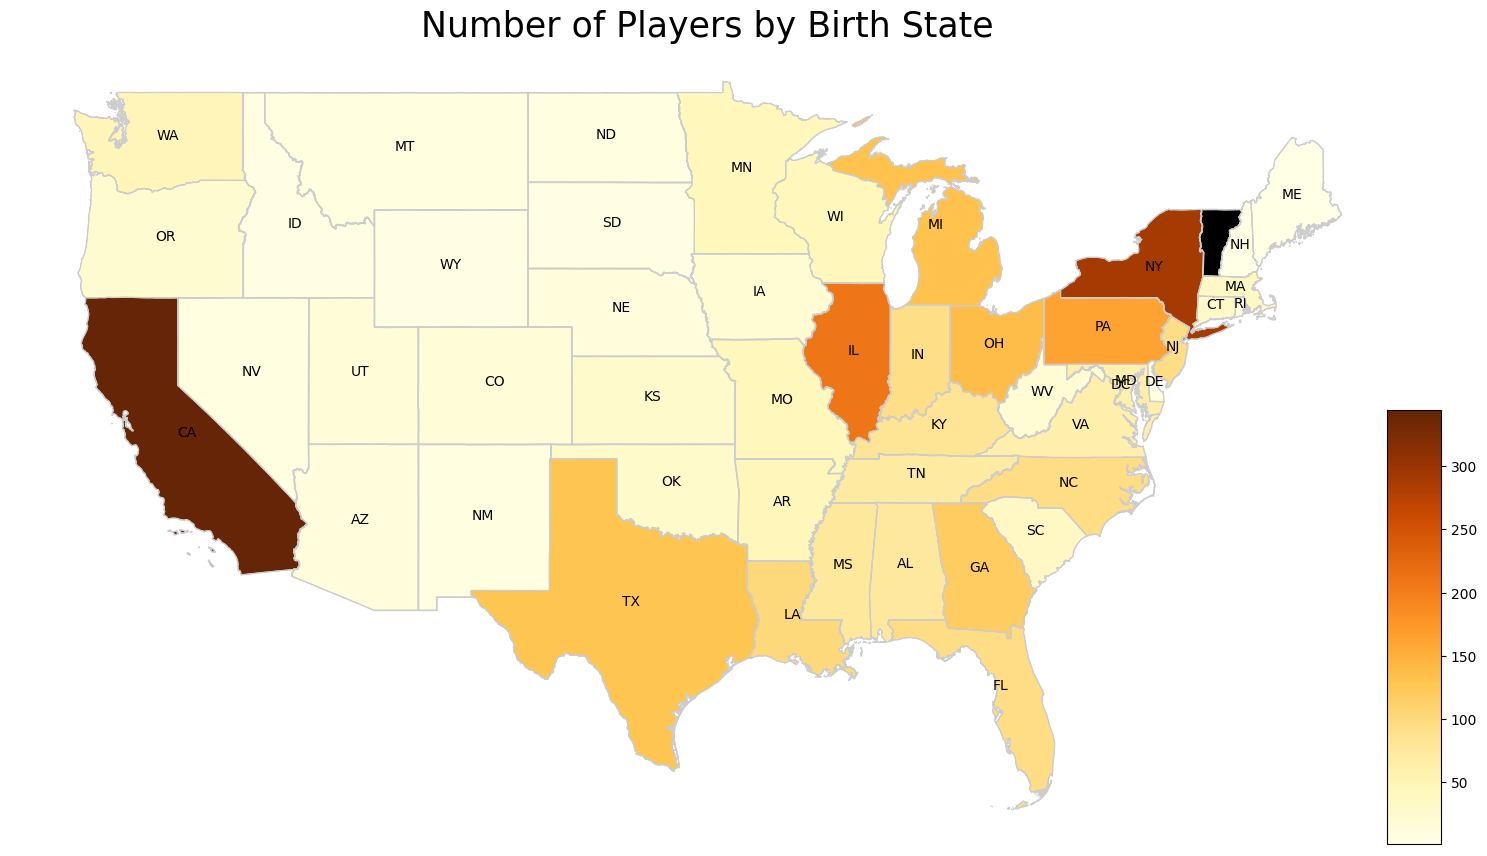

In [241]:
# creating map for birth state
fig, ax = plt.subplots(1, 1, figsize=(18, 14))
map = gdfBirth.boundary.plot(linewidth=0.8, ax=ax, edgecolor='0.8')
ax.axis('off')

# have to iterate through each row in df because the colors do not plot correctly when calling one plot function
for state in gdfBirth.iterrows():
  ax.annotate(text=state[1].STUSPS, xy=state[1].geometry.centroid.coords[0], ha='center', fontsize=10)
  st = gdfBirth[gdfBirth['STUSPS'] == state[1].STUSPS]
  st.plot(color = state[1].color, linewidth=0.8, ax=map, edgecolor='0.8', legend=False)

ax.set_title('Number of Players by Birth State', fontdict={'fontsize': '25', 'fontweight' : '3'})
fig = ax.get_figure()
cbax = fig.add_axes([0.89, 0.21, 0.03, 0.31])
sm = plt.cm.ScalarMappable(cmap='YlOrBr', norm=plt.Normalize(gdfBirth['count'].min(), gdfBirth['count'].max()))
fig.colorbar(sm, cbax)
plt.show()